In [1]:
!pip install pandas scikit-learn

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, recall_score, precision_score, f1_score

from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.calibration import CalibratedClassifierCV

In [4]:
from google.colab import files
import pandas as pd

use_cols = [
    "comment_text", "target",
    "male", "female",
    "black", "white", "asian", "latino",
    "muslim", "christian", "jewish", "hindu", "atheist",
    "bisexual", "heterosexual", "homosexual_gay_or_lesbian"
]

df = pd.read_csv("train.csv", usecols=use_cols)

# Rename
df = df.rename(columns={"comment_text": "text"})

# Label
df["label"] = (df["target"] > 0.5).astype(int)

identity_cols = [
    "male", "female",
    "black", "white", "asian", "latino",
    "muslim", "christian", "jewish", "hindu", "atheist",
    "bisexual", "heterosexual", "homosexual_gay_or_lesbian"
]

df = df[["text", "label"] + identity_cols]

df = df.dropna(subset=["text"])
df[identity_cols] = df[identity_cols].fillna(0)

from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

print("Train shape:", train_df.shape)
print(train_df["label"].value_counts())

Train shape: (1443896, 16)
label
0    1358633
1      85263
Name: count, dtype: int64


In [5]:
#define features
X_train = train_df["text"]
y_train = train_df["label"]

X_test = test_df["text"]
y_test = test_df["label"]

vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words='english'
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


#train model
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),

    "SVM": CalibratedClassifierCV(
        LinearSVC(class_weight="balanced", max_iter=5000)
    ),

    "Naive Bayes": MultinomialNB()
}


model_results = {}

threshold = 0.3

for name, clf in models.items():
  print(f"\nTraining {name}...")

  clf.fit(X_train_vec, y_train)

  probs = clf.predict_proba(X_test_vec)[:, 1]
  preds = (probs > threshold).astype(int)

  temp_results = pd.DataFrame({
    "text": X_test.values,
    "true": y_test.values,
    "pred": preds,
    "prob": probs
  })

  for col in identity_cols:
    temp_results[col] = test_df[col].values

  model_results[name] = temp_results

  print(f"\n{name} Results")
  print("Accuracy:", accuracy_score(y_test, preds))
  print(classification_report(y_test, preds))

# Errors
#errors = results[results['true'] != results['pred']]
#errors.head(10)


Training Logistic Regression...

Logistic Regression Results
Accuracy: 0.8300103885310617
              precision    recall  f1-score   support

           0       0.99      0.83      0.90    339800
           1       0.24      0.91      0.38     21175

    accuracy                           0.83    360975
   macro avg       0.62      0.87      0.64    360975
weighted avg       0.95      0.83      0.87    360975


Training SVM...

SVM Results
Accuracy: 0.9572463466999099
              precision    recall  f1-score   support

           0       0.97      0.98      0.98    339800
           1       0.65      0.58      0.61     21175

    accuracy                           0.96    360975
   macro avg       0.81      0.78      0.80    360975
weighted avg       0.96      0.96      0.96    360975


Training Naive Bayes...

Naive Bayes Results
Accuracy: 0.9509689036636886
              precision    recall  f1-score   support

           0       0.95      1.00      0.97    339800
           1

In [7]:
def compute_fpr(df, group_col):
  group = df[df[group_col] > 0.5]
  non_toxic = group[group["true"] == 0]

  if len(non_toxic) == 0:
    return None

  fp = (non_toxic["pred"] == 1).sum()
  return fp / len(non_toxic)


fpr_comparison = []

for model_name, res in model_results.items():
  overall_non_toxic = res[res["true"] == 0]
  overall_fpr = (overall_non_toxic["pred"] == 1).mean()

  for col in identity_cols:
    fpr = compute_fpr(res, col)
    if fpr is not None:
      fpr_comparison.append({
        "model": model_name,
        "identity_group": col,
        "group_fpr": fpr,
        "overall_fpr": overall_fpr,
        "fpr_disparity": fpr - overall_fpr
      })

fpr_df = pd.DataFrame(fpr_comparison)
fpr_df

,model,identity_group,group_fpr,overall_fpr,fpr_disparity
0,Logistic Regression,male,0.414476,0.174688,0.239787
1,Logistic Regression,female,0.374037,0.174688,0.199349
2,Logistic Regression,black,0.717540,0.174688,0.542852
3,Logistic Regression,white,0.675711,0.174688,0.501023
4,Logistic Regression,asian,0.259601,0.174688,0.084913
5,Logistic Regression,latino,0.426923,0.174688,0.252235
6,Logistic Regression,muslim,0.622236,0.174688,0.447547
7,Logistic Regression,christian,0.244195,0.174688,0.069507
8,Logistic Regression,jewish,0.480430,0.174688,0.305742
9,Logistic Regression,hindu,0.417476,0.174688,0.242788


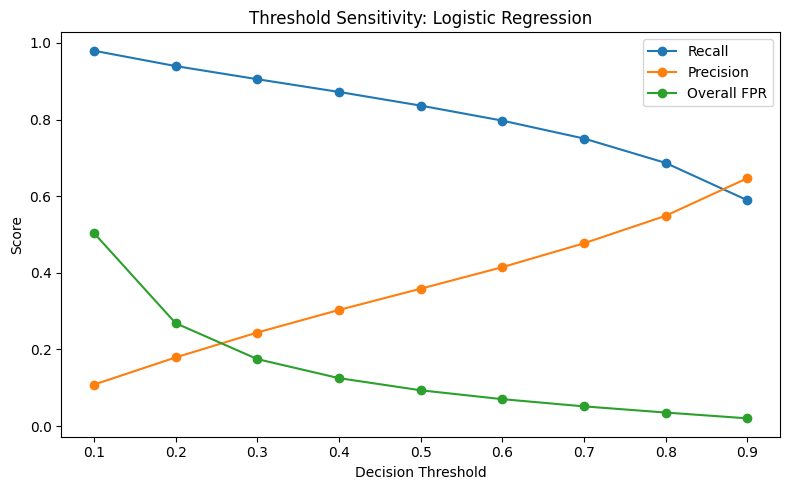

In [20]:
thresholds = [i / 10 for i in range(1, 10)]

threshold_results = []

for model_name, res in model_results.items():
  probs = res["prob"].values
  true = res["true"].values

  for threshold in thresholds:
    preds = (probs > threshold).astype(int)

    temp = res.copy()
    temp["pred"] = preds

    overall_recall = recall_score(true, preds)
    overall_precision = precision_score(true, preds, zero_division=0)
    overall_f1 = f1_score(true, preds, zero_division=0)

    overall_non_toxic = temp[temp["true"] == 0]
    overall_fpr = (overall_non_toxic["pred"] == 1).mean()

    for col in identity_cols:
      group_fpr = compute_fpr(temp, col)

      if group_fpr is not None:
        threshold_results.append({
          "model": model_name,
          "threshold": threshold,
          "identity_group": col,
          "group_fpr": group_fpr,
          "overall_fpr": overall_fpr,
          "fpr_disparity": group_fpr - overall_fpr,
          "recall": overall_recall,
          "precision": overall_precision,
          "f1": overall_f1
        })

threshold_df = pd.DataFrame(threshold_results)
threshold_df.head()


import matplotlib.pyplot as plt

model_name = "Logistic Regression"
subset = threshold_df[threshold_df["model"] == model_name]

summary = subset.groupby("threshold").agg({
    "recall": "mean",
    "precision": "mean",
    "overall_fpr": "mean"
}).reset_index()

plt.figure(figsize=(8, 5))
plt.plot(summary["threshold"], summary["recall"], marker="o", label="Recall")
plt.plot(summary["threshold"], summary["precision"], marker="o", label="Precision")
plt.plot(summary["threshold"], summary["overall_fpr"], marker="o", label="Overall FPR")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Threshold Sensitivity: Logistic Regression")
plt.legend()
plt.tight_layout()
plt.savefig("threshold_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()

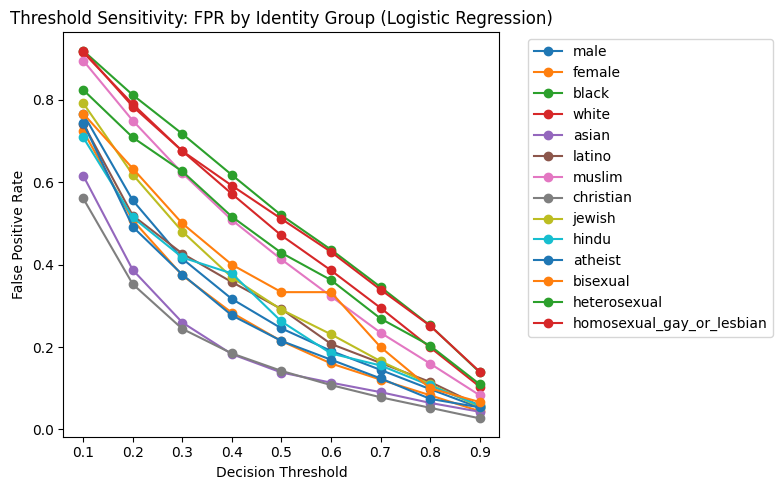

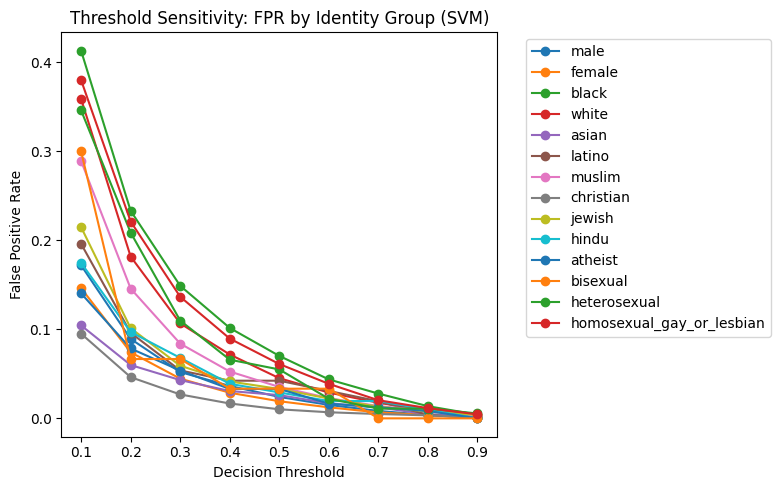

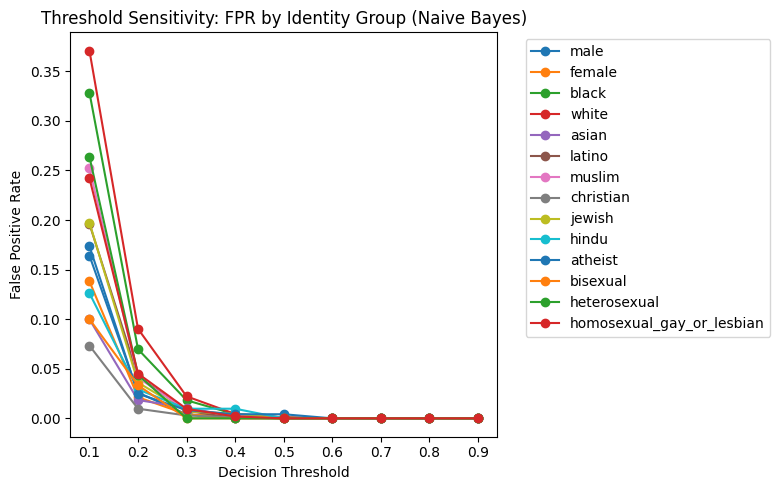

In [10]:
import matplotlib.pyplot as plt

for model_name in threshold_df["model"].unique():
    subset = threshold_df[threshold_df["model"] == model_name]

    plt.figure(figsize=(8, 5))

    for group in identity_cols:
        group_data = subset[subset["identity_group"] == group]
        if len(group_data) > 0:
            plt.plot(
                group_data["threshold"],
                group_data["group_fpr"],
                marker="o",
                label=group
            )

    plt.title(f"Threshold Sensitivity: FPR by Identity Group ({model_name})")
    plt.xlabel("Decision Threshold")
    plt.ylabel("False Positive Rate")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

In [11]:
import re

swap_pairs = [
  # Gender
  ("male", "female"),
  ("man", "woman"),
  ("men", "women"),
  ("boy", "girl"),
  ("father", "mother"),
  ("son", "daughter"),
  ("brother", "sister"),
  ("he", "she"),
  ("him", "her"),
  ("his", "hers"),

  # Race / ethnicity
  ("black", "white"),
  ("asian", "latino"),
  ("latina", "asian"),

  # Religion
  ("muslim", "christian"),
  ("jewish", "christian"),
  ("hindu", "christian"),
  ("atheist", "christian"),

  # Sexual orientation
  ("homosexual", "heterosexual"),
  ("bisexual", "heterosexual"),
  ("gay", "straight"),
  ("lesbian", "straight")
]

swaps = {}
for a, b in swap_pairs:
  swaps[a] = b
  swaps[b] = a


def preserve_case(original, replacement):
  if original.isupper():
    return replacement.upper()
  elif original[0].isupper():
    return replacement.capitalize()
  else:
    return replacement


def swap_identity(text):
  def replace(match):
    word = match.group(0)
    lower = word.lower()

    if lower in swaps:
      replacement = swaps[lower]
      return preserve_case(word, replacement)

    # Handle simple plural forms
    if lower.endswith("s"):
      base = lower[:-1]
      if base in swaps:
        replacement = swaps[base] + "s"
        return preserve_case(word, replacement)

    return word

  return re.sub(r"\b\w+\b", replace, text)


# ---- Counterfactual Consistency Test ----
swapped_texts = [swap_identity(t) for t in test_df["text"].tolist()]
X_swapped_vec = vectorizer.transform(swapped_texts)

for model_name, clf in models.items():
  print(f"\nCounterfactual test for {model_name}")

  original_results = model_results[model_name]

  swapped_probs = clf.predict_proba(X_swapped_vec)[:, 1]
  swapped_pred = (swapped_probs > 0.3).astype(int)

  original_results["swapped_pred"] = swapped_pred
  original_results["prediction_flipped"] = (
    original_results["pred"] != original_results["swapped_pred"]
  ).astype(int)

  flip_rate = original_results["prediction_flipped"].mean()

  print(f"Overall flip rate: {flip_rate:.3f}")

  for col in identity_cols:
    group = original_results[original_results[col] > 0.5]
    if len(group) > 0:
      group_flip_rate = group["prediction_flipped"].mean()
      print(f"{col}: {group_flip_rate:.3f} ({len(group)} samples)")


Counterfactual test for Logistic Regression
Overall flip rate: 0.009
male: 0.050 (8063 samples)
female: 0.045 (10119 samples)
black: 0.068 (2808 samples)
white: 0.055 (4727 samples)
asian: 0.036 (701 samples)
latino: 0.049 (285 samples)
muslim: 0.173 (3916 samples)
christian: 0.050 (6995 samples)
jewish: 0.060 (1445 samples)
hindu: 0.116 (112 samples)
atheist: 0.085 (260 samples)
bisexual: 0.212 (33 samples)
heterosexual: 0.211 (213 samples)
homosexual_gay_or_lesbian: 0.337 (1964 samples)

Counterfactual test for SVM
Overall flip rate: 0.003
male: 0.026 (8063 samples)
female: 0.017 (10119 samples)
black: 0.043 (2808 samples)
white: 0.050 (4727 samples)
asian: 0.014 (701 samples)
latino: 0.035 (285 samples)
muslim: 0.062 (3916 samples)
christian: 0.017 (6995 samples)
jewish: 0.035 (1445 samples)
hindu: 0.036 (112 samples)
atheist: 0.019 (260 samples)
bisexual: 0.030 (33 samples)
heterosexual: 0.127 (213 samples)
homosexual_gay_or_lesbian: 0.146 (1964 samples)

Counterfactual test for N

In [13]:
model = models["Logistic Regression"]

feature_names = vectorizer.get_feature_names_out()
coefs = model.coef_[0]

feature_importance = pd.DataFrame({
  "feature": feature_names,
  "coefficient": coefs
})

top_toxic_features = feature_importance.sort_values(
  by="coefficient",
  ascending=False
).head(50)

top_toxic_features

identity_terms = [
  "male", "female", "man", "woman", "men", "women", "boy", "girl",
  "black", "white", "asian", "latino", "latina",
  "muslim", "muslims", "christian", "christians",
  "jewish", "jews", "hindu", "hindus", "atheist", "atheists",
  "bisexual", "heterosexual", "homosexual", "gay", "lesbian", "straight"
]

top_toxic_features["is_identity_term"] = top_toxic_features["feature"].isin(identity_terms)

identity_feature_count = top_toxic_features["is_identity_term"].sum()
identity_feature_percentage = identity_feature_count / len(top_toxic_features)

print("Identity terms in top 50 toxic features:", identity_feature_count)
print("Percentage:", identity_feature_percentage)


def remove_identity_terms(text):
  pattern = r"\b(" + "|".join(identity_terms) + r")\b"
  return re.sub(pattern, "", text, flags=re.IGNORECASE)

X_train_ablate = X_train.apply(remove_identity_terms)
X_test_ablate = X_test.apply(remove_identity_terms)

ablate_vectorizer = TfidfVectorizer(
  max_features=10000,
  stop_words="english"
)

X_train_ablate_vec = ablate_vectorizer.fit_transform(X_train_ablate)
X_test_ablate_vec = ablate_vectorizer.transform(X_test_ablate)

ablate_model = LogisticRegression(max_iter=1000, class_weight="balanced")
ablate_model.fit(X_train_ablate_vec, y_train)

ablate_probs = ablate_model.predict_proba(X_test_ablate_vec)[:, 1]
ablate_pred = (ablate_probs > 0.3).astype(int)

ablate_results = pd.DataFrame({
  "text": X_test.values,
  "true": y_test.values,
  "pred": ablate_pred,
  "prob": ablate_probs
})

for col in identity_cols:
  ablate_results[col] = test_df[col].values

ablation_comparison = []

original_results = model_results["Logistic Regression"]

for col in identity_cols:
  original_fpr = compute_fpr(original_results, col)
  ablated_fpr = compute_fpr(ablate_results, col)

  if original_fpr is not None and ablated_fpr is not None:
    ablation_comparison.append({
      "identity_group": col,
      "original_fpr": original_fpr,
      "ablated_fpr": ablated_fpr,
      "fpr_change": ablated_fpr - original_fpr
    })

ablation_df = pd.DataFrame(ablation_comparison)
ablation_df

Identity terms in top 50 toxic features: 0
Percentage: 0.0


,identity_group,original_fpr,ablated_fpr,fpr_change
0,male,0.414476,0.318572,-0.095904
1,female,0.374037,0.307066,-0.066971
2,black,0.717540,0.495672,-0.221868
3,white,0.675711,0.519697,-0.156014
4,asian,0.259601,0.250384,-0.009217
5,latino,0.426923,0.396154,-0.030769
6,muslim,0.622236,0.416617,-0.205619
7,christian,0.244195,0.222188,-0.022006
8,jewish,0.480430,0.356869,-0.123561
9,hindu,0.417476,0.310680,-0.106796


DISTILLIBERT:

In [15]:
!pip install transformers datasets evaluate -q

import torch
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from transformers import TrainingArguments, Trainer
from datasets import Dataset
import numpy as np

In [19]:
train_sample = train_df.sample(n=50000, random_state=42)
test_sample = test_df.sample(n=10000, random_state=42)

train_dataset = Dataset.from_pandas(train_sample[["text", "label"]])
test_dataset = Dataset.from_pandas(test_sample[["text", "label"]])

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset = train_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])


bert_model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)


training_args = TrainingArguments(
    output_dir="./distilbert_jigsaw",

    # These must match when load_best_model_at_end=True
    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    weight_decay=0.01,

    logging_dir="./logs",
    logging_steps=100,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True
)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0)
    }


trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()


predictions = trainer.predict(test_dataset)

logits = predictions.predictions
probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()

distilbert_pred = (probs > 0.3).astype(int)


distilbert_results = pd.DataFrame({
    "text": test_sample["text"].values,
    "true": test_sample["label"].values,
    "pred": distilbert_pred,
    "prob": probs
})

for col in identity_cols:
    distilbert_results[col] = test_sample[col].values


print("DistilBERT Results")
print(classification_report(distilbert_results["true"], distilbert_results["pred"]))

for col in identity_cols:
    fpr = compute_fpr(distilbert_results, col)
    if fpr is not None:
        print(f"{col} FPR: {fpr:.3f}")

model_results["DistilBERT"] = distilbert_results

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but n

Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 